In [1]:
import warnings
warnings.filterwarnings('ignore')

# Project Title: **Handwritten Math Expression Solver**
---

## Author Information
- **Name**: Rudra Kachhia
- **Enrollment No.**: 12302040501054
- **Course title and Subject code**: ARTIFICIAL INTELLIGENCE AND MACHINE LEARNING (202046702)
- **Guided by**: Ms. Divya Dubal

---

### Importing necessary libraries 

In [2]:
# for storing and manipulating Dataset
import numpy as np
import pandas as pd

# For image processing (OpenCV)
import cv2
from skimage.feature import hog

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML classes and functions (scikit-learn)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# For model deployment
import joblib

# for path handling like os
import os

### Constants 

In [3]:
DIR = "MAIN_DATASET"
MODEL_PATH = "MAIN_MODEL.pkl"

---
## Machine learning Pipelines
---

### 1. loading and preparing data

In [4]:
IMG_SIZE = (64, 64)

def preprocess_image(img):
    img = np.asarray(img, dtype=np.uint8)

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )[1]
    
    coords = cv2.findNonZero(img)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img


def extract_hog_features(img):
    img = img.astype(np.float32) / 255.0
    
    feat = hog(img, feature_vector=True)

    return feat.astype(np.float32)

In [5]:
data = []
labels = []

for folder in os.listdir(DIR):
    path = os.path.join(DIR, folder)
    if os.path.isdir(path):
        files = os.listdir(path)
        print(f'loading data from "{path}" having {len(files)} images')

        for image in files:
            img_path = os.path.join(path, image)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            processed_image = preprocess_image(img)
            if processed_image is not None:
                hog_features = extract_hog_features(processed_image)
                data.append(hog_features)
                labels.append(folder)

data = np.array(data, dtype=np.float32)
labels = np.array(labels)

loading data from "MAIN_DATASET/div" having 868 images
loading data from "MAIN_DATASET/9" having 1000 images
loading data from "MAIN_DATASET/0" having 1000 images
loading data from "MAIN_DATASET/7" having 1000 images
loading data from "MAIN_DATASET/+" having 1001 images
loading data from "MAIN_DATASET/6" having 1000 images
loading data from "MAIN_DATASET/1" having 1000 images
loading data from "MAIN_DATASET/8" having 1000 images
loading data from "MAIN_DATASET/-" having 1000 images
loading data from "MAIN_DATASET/*" having 1000 images
loading data from "MAIN_DATASET/4" having 1000 images
loading data from "MAIN_DATASET/3" having 1000 images
loading data from "MAIN_DATASET/2" having 1000 images
loading data from "MAIN_DATASET/5" having 1000 images


In [6]:
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Classes: {np.unique(labels)}")

Data shape: (13868, 2916)
Labels shape: (13868,)
Classes: ['*' '+' '-' '0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'div']


---
### 2. Complete data preprocessing pipeline and Model training

In [7]:
X = data
le = LabelEncoder()
y = le.fit_transform(labels)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=12
)

In [9]:
clf = LinearSVC(C=0.1, class_weight="balanced", max_iter=20000, dual=False)
clf.fit(X_train, y_train)

print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (11094, 2916), Testing set: (2774, 2916)


---
### 3. Model Evaluation

In [10]:
y_pred = clf.predict(X_test)

Classification Report:
              precision    recall  f1-score   support

           *       0.97      0.99      0.98       200
           +       0.97      0.96      0.96       200
           -       0.94      0.98      0.96       200
           0       0.98      0.98      0.98       200
           1       0.97      0.92      0.94       200
           2       0.97      0.98      0.98       200
           3       0.98      0.97      0.98       200
           4       1.00      0.97      0.98       200
           5       0.99      0.96      0.98       200
           6       0.98      0.98      0.98       200
           7       0.97      0.98      0.98       200
           8       0.99      0.99      0.99       200
           9       0.97      0.99      0.98       200
         div       1.00      1.00      1.00       174

    accuracy                           0.98      2774
   macro avg       0.98      0.98      0.98      2774
weighted avg       0.98      0.98      0.98      2774



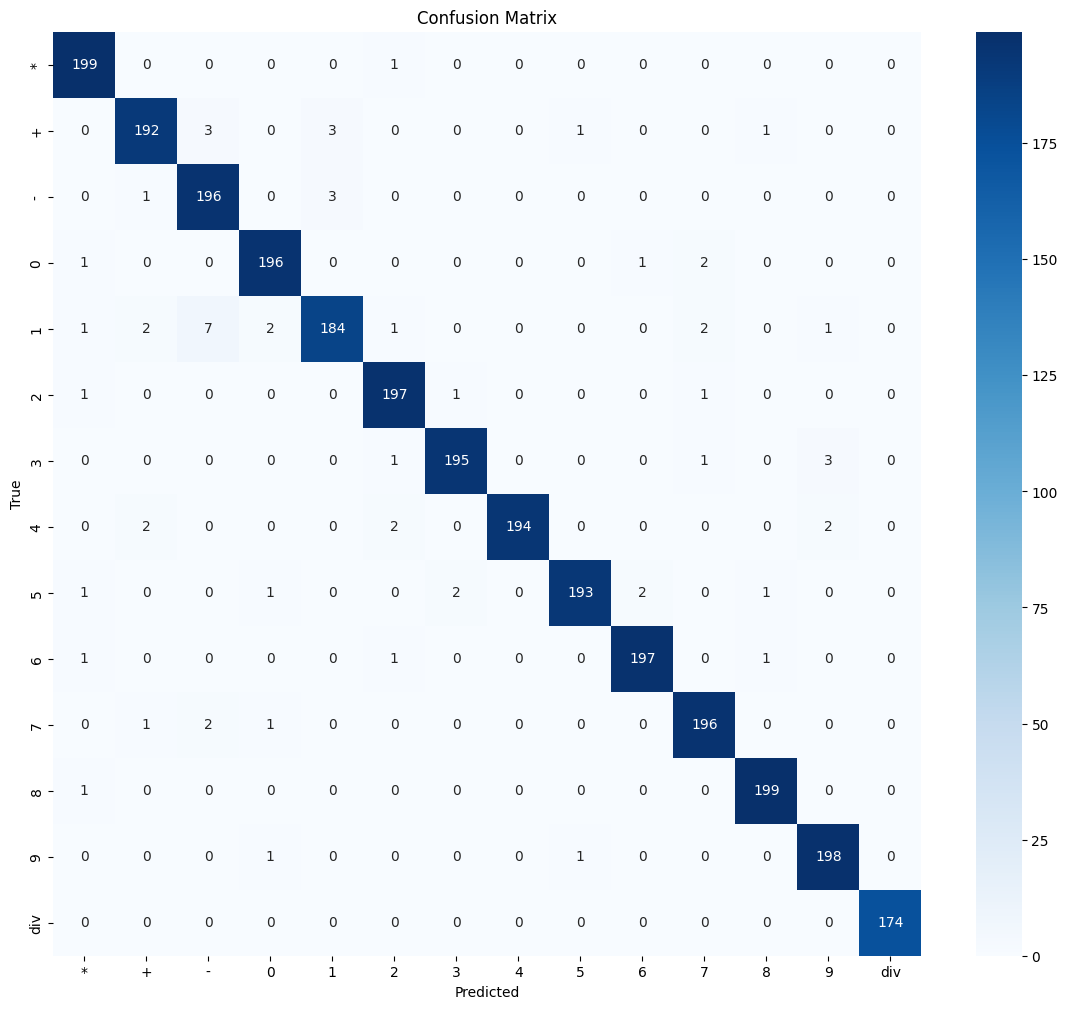

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

---
### 4. Model Deployment

In [12]:
joblib.dump((clf, le), MODEL_PATH)
print(f"Model saved as {MODEL_PATH}")

Model saved as MAIN_MODEL.pkl


---
---
---

# **Testing the Model using Inputs**

### Importing necessary libraries

In [5]:
import os
from ipycanvas import Canvas
import ipywidgets as widgets
from IPython.display import display
import joblib

### Loading trained model

In [6]:
clf, le = joblib.load(MODEL_PATH)

### Character segmentation from expression

In [7]:
def segment_characters(image_path, padding=5, min_area=50, merge_gap=10):
    raw = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if raw is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    blurred = cv2.GaussianBlur(raw, (5, 5), 0)
    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    raw_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area >= min_area:
            x, y, w, h = cv2.boundingRect(cnt)
            raw_boxes.append((x, y, w, h))

    if not raw_boxes:
        raise ValueError("No characters detected — try a cleaner image.")

    raw_boxes.sort(key=lambda b: b[0])

    merged_boxes = []
    cur_x, cur_y, cur_w, cur_h = raw_boxes[0]

    for (x, y, w, h) in raw_boxes[1:]:
        gap = x - (cur_x + cur_w)
        if gap <= merge_gap:
            new_x = min(cur_x, x)
            new_y = min(cur_y, y)
            new_x2 = max(cur_x + cur_w, x + w)
            new_y2 = max(cur_y + cur_h, y + h)
            cur_x, cur_y = new_x, new_y
            cur_w, cur_h = new_x2 - new_x, new_y2 - new_y
        else:
            merged_boxes.append((cur_x, cur_y, cur_w, cur_h))
            cur_x, cur_y, cur_w, cur_h = x, y, w, h

    merged_boxes.append((cur_x, cur_y, cur_w, cur_h))

    H, W = raw.shape
    segments = []
    final_boxes = []

    for (x, y, w, h) in merged_boxes:
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(W, x + w + padding)
        y2 = min(H, y + h + padding)

        crop = raw[y1:y2, x1:x2]
        processed = preprocess_image(crop)
        segments.append(processed)
        final_boxes.append((x1, y1, x2 - x1, y2 - y1))

    return segments, final_boxes

### predict character using trained model

In [8]:
def predict_symbol(segment_img):
    processed = preprocess_image(segment_img)
    features = extract_hog_features(processed).reshape(1, -1)
    pred = clf.predict(features)
    return le.inverse_transform(pred)[0]

### Visualize the result

In [9]:
def visualize_result(image_path, result_dict):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    img_c = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for i, ((x, y, w, h), label) in enumerate(zip(result_dict["boxes"], result_dict["labels"])):
        cv2.rectangle(img_c, (x, y), (x + w, y + h),(0, 255, 0), 2)
        cv2.putText(img_c, label, (x, max(y - 6, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    title = result_dict["expression"] + " = " + str(result_dict['result'])

    plt.title(title, fontsize=16, fontweight="bold", pad=12)
    plt.show()

### Solve the expression from image and display result

In [10]:
def solve_expression_image(image_path):
    print(f"Solving: {image_path}\n")

    segments, boxes = segment_characters(image_path)
    
    print(f"1. Detected {len(segments)} character(s)")

    predicted_labels = [predict_symbol(i) for i in segments]
    print(f"2. Predicted labels: {predicted_labels}")

    expr = "".join(predicted_labels).replace("div","/")
    print(f"3. Expression: {expr}")

    print(f"{'='*40}")
    result = eval(expr)
    print(f"4. Result: {result}")
    print(f"{'='*40}\n")
    visualize_result(image_path, {
        "labels": predicted_labels,
        "expression": expr,
        "result": result,
        "boxes": boxes,
    })

### Canvas for drawing expression

In [11]:
SAVE_PATH = "assets/expression.png"
os.makedirs("assets", exist_ok=True)

width, height = 600, 120
canvas = Canvas(width=width, height=height, sync_image_data=True)

canvas.fill_style = "white"
canvas.fill_rect(0, 0, width, height)

canvas.stroke_style = "#ddd"
canvas.set_line_dash([4, 4])
canvas.stroke_line(10, height - 15, width - 10, height - 15)
canvas.set_line_dash([])

canvas.stroke_style = "black"
canvas.line_width = 6

drawing = {"active": False, "x": None, "y": None}

def on_mouse_down(x, y):
    drawing["active"] = True
    drawing["x"], drawing["y"] = x, y

def on_mouse_move(x, y):
    if drawing["active"] and drawing["x"] is not None:
        canvas.stroke_line(drawing["x"], drawing["y"], x, y)
        drawing["x"], drawing["y"] = x, y

def on_mouse_up(x, y):
    drawing["active"] = False
    drawing["x"], drawing["y"] = None, None

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

result_output = widgets.Output()

def reset_canvas():
    canvas.clear()
    canvas.fill_style = "white"
    canvas.fill_rect(0, 0, width, height)
    canvas.stroke_style = "#ddd"
    canvas.set_line_dash([4, 4])
    canvas.stroke_line(10, height - 15, width - 10, height - 15)
    canvas.set_line_dash([])
    canvas.stroke_style = "black"
    canvas.line_width = 6

def clear_canvas(b):
    with result_output:
        result_output.clear_output()
        reset_canvas()

def save_and_solve(b):
    with result_output:
        result_output.clear_output()
        canvas.to_file(SAVE_PATH)

        solve_expression_image(SAVE_PATH)

save_btn = widgets.Button(description="Save & Solve")
clear_btn = widgets.Button(description="Clear")

save_btn.on_click(save_and_solve)
clear_btn.on_click(clear_canvas)

display(widgets.VBox([
    canvas,
    widgets.HBox([save_btn, clear_btn]),
    result_output
]))